### Develop a structure based social media analytics model for any business. Build models for community detection and influence analysis using libraries like NetworkX, Gephi, pr Neo4j. Analyze social media graphs and connections using APIs like LinkedIn API or Twitter API v2

In [ ]:
import pandas as pd

df_posts = pd.read_csv('/content/drive/MyDrive/SMA_DATASET/merged_questions.csv')
df_comments = pd.read_csv('/content/drive/MyDrive/SMA_DATASET/merged_comments.csv')

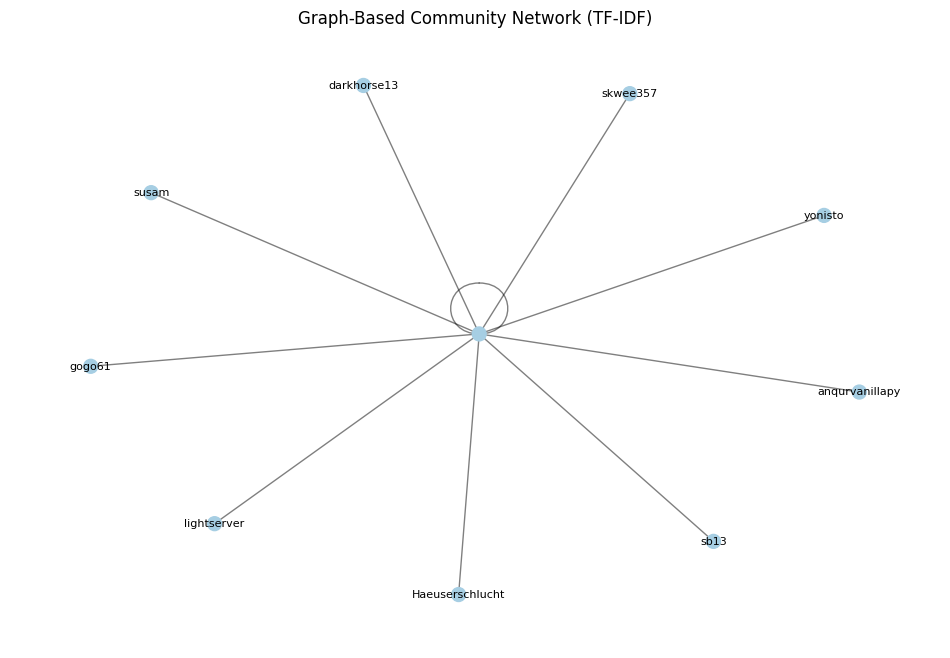

In [ ]:
import networkx as nx
import community.community_louvain as louvain
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

posts_info = df_posts.groupby('User')['Question'].apply(' '.join).reset_index(name='PostsText')
comments_info = df_comments.groupby('Author')['Comment'].apply(' '.join).reset_index(name='CommentsText')
user_activity = pd.merge(posts_info, comments_info, left_on='User', right_on='Author', how='outer').fillna('')
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(user_activity['PostsText'] + ' ' + user_activity['CommentsText'])
cosine_similarities = cosine_similarity(tfidf_matrix, tfidf_matrix)
G = nx.Graph()
for i in range(len(user_activity)):
    for j in range(i + 1, len(user_activity)):
        similarity = cosine_similarities[i, j]
        if similarity > 0.2:
            G.add_edge(user_activity['User'][i], user_activity['User'][j])

partition = louvain.best_partition(G)
user_activity['Community'] = user_activity['User'].map(partition)
pos = nx.spring_layout(G)
plt.figure(figsize=(12, 8))

# Draw nodes colored by community
colors = [partition[node] for node in G.nodes]
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.cm.Paired, node_size=100)
nx.draw_networkx_edges(G, pos, alpha=0.5)
labels = {node: user_activity.loc[user_activity['User'] == node, 'User'].values[0] for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title('Graph-Based Community Network (TF-IDF)')
plt.axis('off')
plt.show()

In [ ]:
user_activity

,User,PostsText,Author,CommentsText,Community
0,,,0100101101001,I'm working on a browser extension that aims t...,0.0
1,,,01jonny01,I'd rather put up with the speeding than aaski...,0.0
2,,,101008,"A Django UI Desktop app, a là Docker Desktop, ...",0.0
3,,,147,I'm in the early stages of working on a Kubern...,0.0
4,,,234120987654,Fine-tuning an LLM to create long-form podcast...,0.0
...,...,...,...,...,...
789,,,zciwor,I'm working on cataloging open source hardware...,0.0
790,,,zer0x4d,An ode to DreamweaverDreamweaver was how I lea...,0.0
791,,,zft,That's super nice. Can I eventually replace my...,0.0
792,,,zimpenfish,"To save the grep, you can do:sed -Ene 's/^loca...",0.0


In [ ]:
comments_per_link = df_comments.groupby('Link')['Comment'].count().reset_index()
df_combined = pd.merge(df_posts, comments_per_link, on='Link', how='outer').fillna(0)
df_combined['InfluenceScore'] = df_combined['Score'] + df_combined['Comment']
most_influential_user = df_combined.groupby('User')['InfluenceScore'].sum().idxmax()
print(df_combined.head(2))
print()
print(f"The most influential user is: {most_influential_user}")

                                               Title         User  \
0  Ask HN: What fiction/non-fiction book should e...   Eavolution   
1  Ask HN: Can I really create a company around m...  darkhorse13   

  Relative time        Date      Time  Score  \
0    7 days ago  2025-02-18  00:40:33     35   
1    4 days ago  2025-02-18  08:37:01     73   

                                            Link  \
0  https://news.ycombinator.com/item?id=43084739   
1  https://news.ycombinator.com/item?id=43087383   

                                            Question  Comment  InfluenceScore  
0  This should be interpreted in the broadest sen...     50.0            85.0  
1  This is a serious question because I'll be the...    124.0           197.0  

The most influential user is: david927


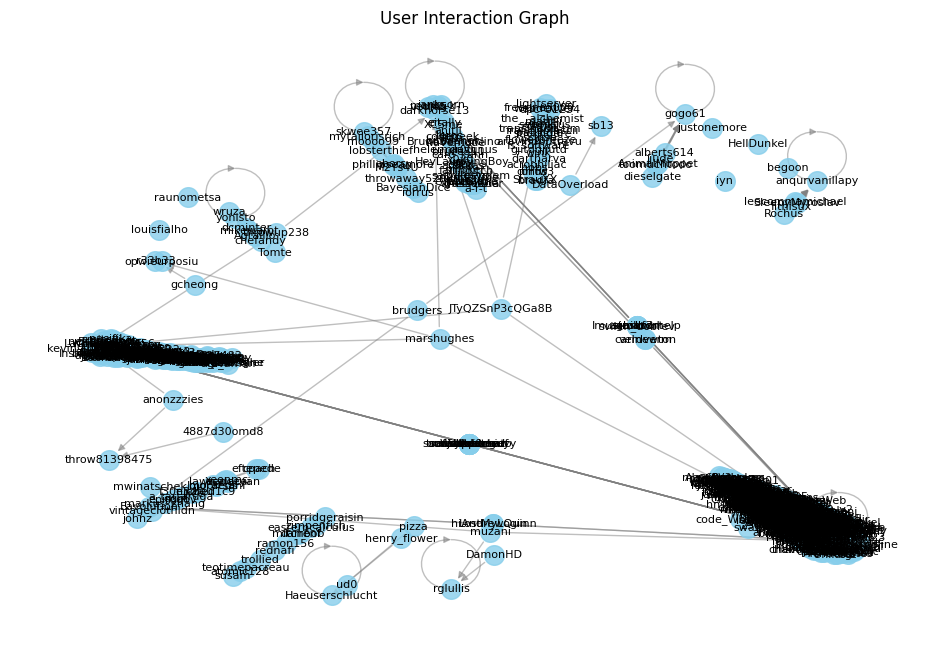

In [ ]:
G = nx.DiGraph()

users = set(df_posts['User']).union(set(df_comments['Author']))
G.add_nodes_from(users)

for index, row in df_comments.iterrows():
    G.add_edge(row['Author'], df_posts.loc[df_posts['Link'] == row['Link'], 'User'].values[0])

pos = nx.spring_layout(G)
plt.figure(figsize=(12, 8))

nx.draw_networkx_nodes(G, pos, node_size=200, node_color='skyblue', alpha=0.8)
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title('User Interaction Graph')
plt.axis('off')
plt.show()

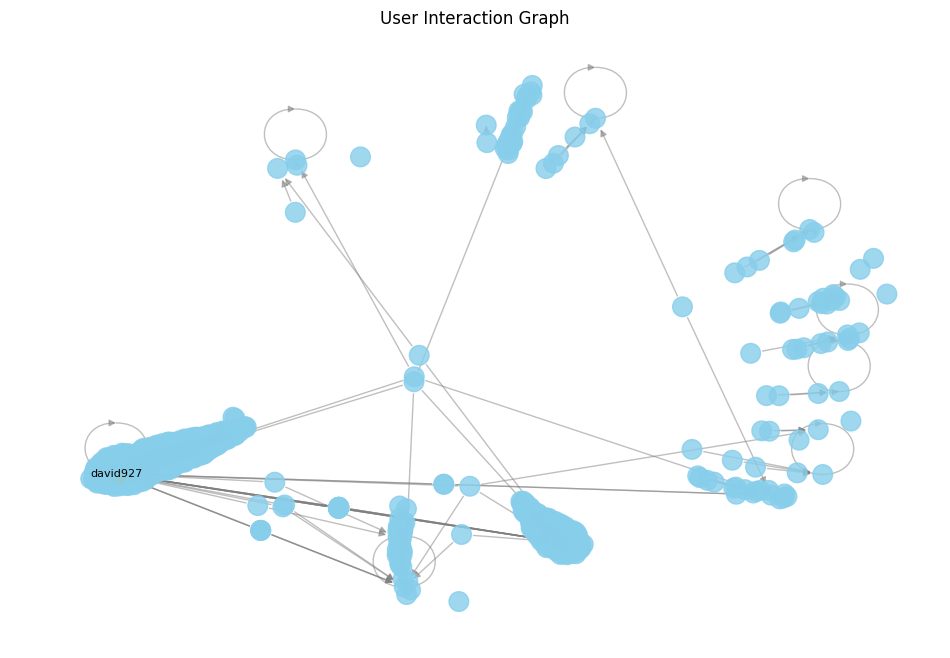

In [ ]:
G = nx.DiGraph()

users = set(df_posts['User']).union(set(df_comments['Author']))
G.add_nodes_from(users)

for index, row in df_comments.iterrows():
    G.add_edge(row['Author'], df_posts.loc[df_posts['Link'] == row['Link'], 'User'].values[0])

max_in_degree_node = max(dict(G.in_degree()).items(), key=lambda x: x[1])[0]

pos = nx.spring_layout(G)
plt.figure(figsize=(12, 8))

node_colors = ['orange' if node == max_in_degree_node else 'skyblue' for node in G.nodes]
nx.draw_networkx_nodes(G, pos, node_size=200, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5, edge_color='gray')

labels = {max_in_degree_node: max_in_degree_node}
nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title('User Interaction Graph')
plt.axis('off')
plt.show()

Centrality Metrics for Influence Analysis

In [ ]:
pagerank_scores = nx.pagerank(G)
most_influential = max(pagerank_scores, key=pagerank_scores.get)
print(f"Most influential user based on PageRank: {most_influential}")


Most influential user based on PageRank: david927


In [ ]:
!pip install prophet

Time-Series Trend Analysis

/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1133: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  self.history_dates = pd.to_datetime(pd.Series(df['ds'].unique(), name='ds')).sort_values()
/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:287: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ds'] = pd.to_datetime(df['ds'])
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observation

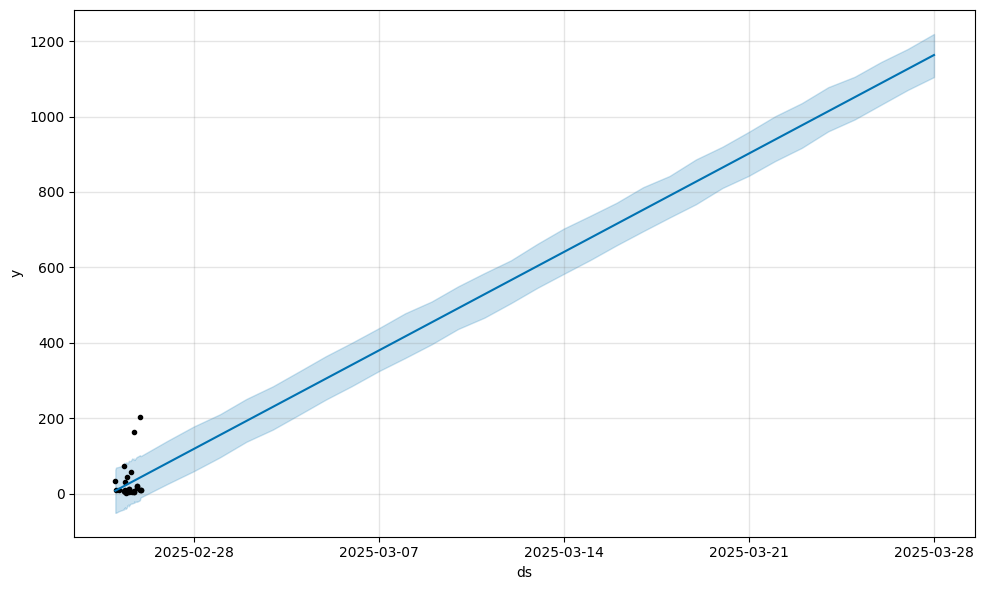

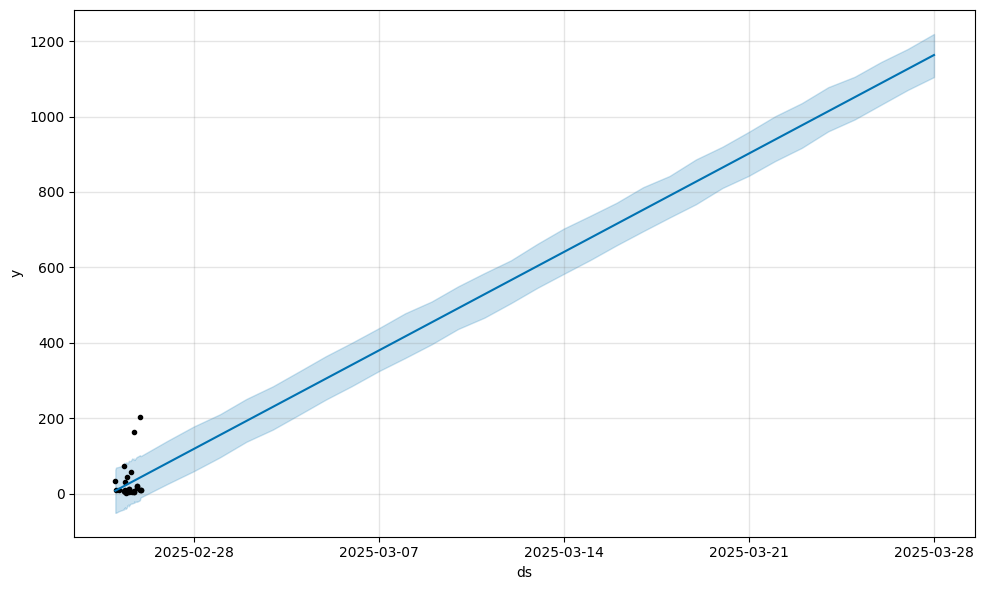

In [ ]:
from prophet import Prophet

df_trend = df_posts[['Time', 'Score']]
df_trend.columns = ['ds', 'y']

model = Prophet()
model.fit(df_trend)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

model.plot(forecast)


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=5)
topics = lda.fit_transform(tfidf_matrix)


In [ ]:
nx.write_gexf(G, "social_graph.gexf")
